In [3]:
!git clone https://github.com/aishindi/ai-saas-ad-strategy-copilot.git
%cd ai-saas-ad-strategy-copilot
!pip install -q -r requirements.txt

Cloning into 'ai-saas-ad-strategy-copilot'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 118 (delta 27), reused 107 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 78.62 KiB | 4.91 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/ai-saas-ad-strategy-copilot/ai-saas-ad-strategy-copilot
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.6 MB/s eta 0:00:00


In [4]:
!apt-get update -qq
!apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(8)
print("Ollama server started")

!ollama pull mistral
!ollama pull llama3
!ollama list

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 56 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (7,208 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> I

In [5]:
import os

os.environ["MODEL_MODE"] = "ollama"
os.environ["MODEL_SMALL"] = "mistral"
os.environ["MODEL_LARGE"] = "llama3"
os.environ["WEB_SEARCH_MODE"] = "mock"

In [6]:
!python database/seed_data.py

Database seeded successfully.


In [7]:
!python -m evaluation.run_evaluation

Running standard evaluation...
Running cache experiment...
Running security tests...
All evaluation files saved in: evaluation_results


In [8]:
!python evaluation/plot_results.py

Loaded: evaluation_results/standard_results_20260517_215703.json
Loaded: evaluation_results/cache_results_20260517_215703.json
Saved model_latency.png
Saved prompt_strategy_scores.png
Saved cache_comparison.png
Done. Plots saved in evaluation_results/plots


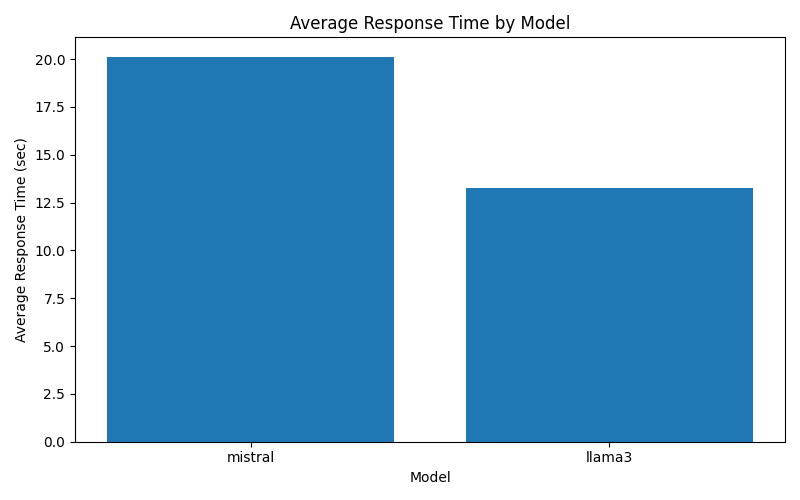

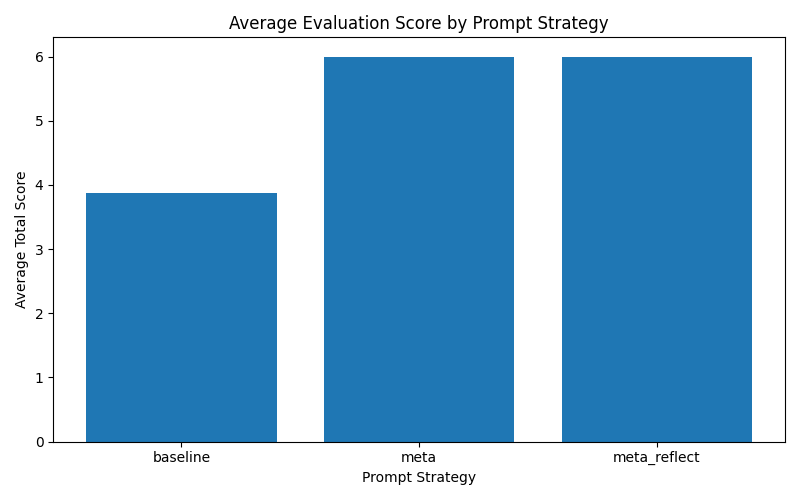

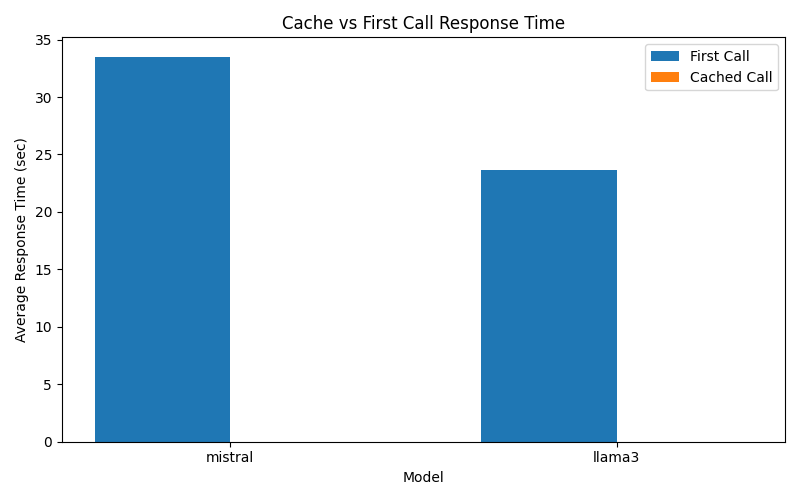

In [9]:
from IPython.display import Image, display
import os

plot_paths = [
    "evaluation_results/plots/model_latency.png",
    "evaluation_results/plots/prompt_strategy_scores.png",
    "evaluation_results/plots/cache_comparison.png",
]

for path in plot_paths:
    if os.path.exists(path):
        display(Image(path))
    else:
        print("Missing:", path)

In [10]:
!zip -r evaluation_results.zip evaluation_results

  adding: evaluation_results/ (stored 0%)
  adding: evaluation_results/cache_results_20260517_215703.json (deflated 79%)
  adding: evaluation_results/.DS_Store (deflated 85%)
  adding: evaluation_results/security_results_20260517_215703.json (deflated 74%)
  adding: evaluation_results/plots/ (stored 0%)
  adding: evaluation_results/plots/cache_comparison.png (deflated 19%)
  adding: evaluation_results/plots/model_latency.png (deflated 20%)
  adding: evaluation_results/plots/prompt_strategy_scores.png (deflated 20%)
  adding: evaluation_results/standard_results_20260517_215703.json (deflated 81%)


In [11]:
from google.colab import files
files.download("evaluation_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>